In [6]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.config import np, plt, sp
import src.simulations as sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
a, p = sp.symbols('a p') # arrival and access probabilities symbols

P = sp.Matrix([
    [(1-a)**2,    a*(1-a),          a*(1-a),          a**2              ],
    [p*(1-a)**2,  (1-a)*(1-p+p*a),  p*a*(1-a),        a*(1-p+p*a)       ],
    [p*(1-a)**2,  p*a*(1-a),        (1-a)*(1-p+p*a),  a*(1-p+p*a)       ],
    [0,           p*(1-a)*(1-p),    p*(1-p)*(1-a),    p**2 + (1-p)*(1-p+2*p*a) ]
])

pi00s, pi01s, pi10s, pi11s = sp.symbols('pi00 pi01 pi10 pi11')
pi = sp.Matrix([pi00s, pi01s, pi10s, pi11s])

# equações: pi = pi P  e soma(pi)=1
eqs = list((pi.T * P - pi.T)[0,:])
eqs[-1] = pi00s + pi01s + pi10s + pi11s - 1
sol = sp.solve(eqs, [pi00s, pi01s, pi10s, pi11s], dict=True)
sol = sol[0]  # dicionário com pi00,pi01,pi10,pi11
pi00, pi01, pi10, pi11 = [sol[pi00s], sol[pi01s], sol[pi10s], sol[pi11s]]

In [ ]:
throughput_expr = sp.simplify(pi01*p + pi10*p + 2*pi11*p*(1-p))
throughput_data = simulate_metric(sim.throughput, time=200000, method="numpy")

In [42]:
p_vals = np.arange(.1, 1, .1)
a_vals = np.arange(0.1, 1.0, 0.1)
print(p_vals)
print(a_vals)

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


# Issue:
a função de simulação não está correta, está imprimindo dados fora do certo

19


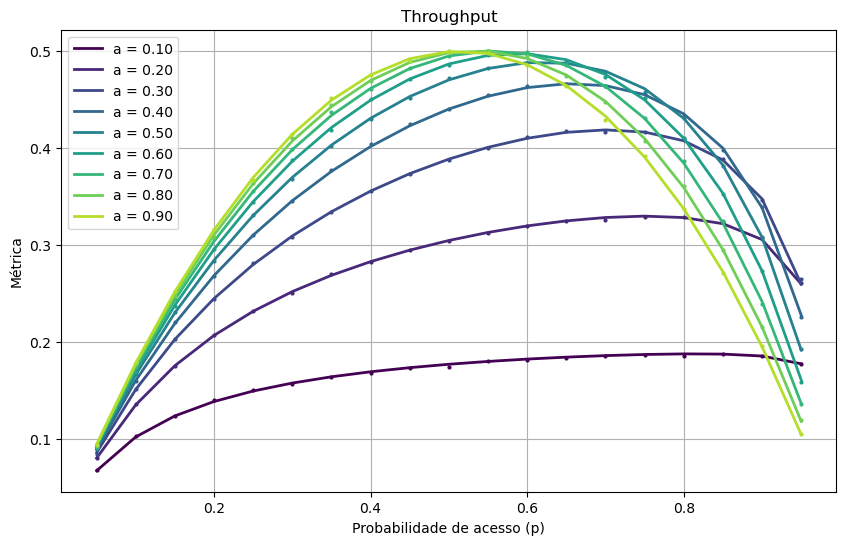

In [52]:
compare_metric_plot(
    analytical_expr=throughput_expr,
    simulated_data=throughput_data,
    title="Throughput",
    cmap="viridis",
    axis="p"
)

## throughput que deu certo:

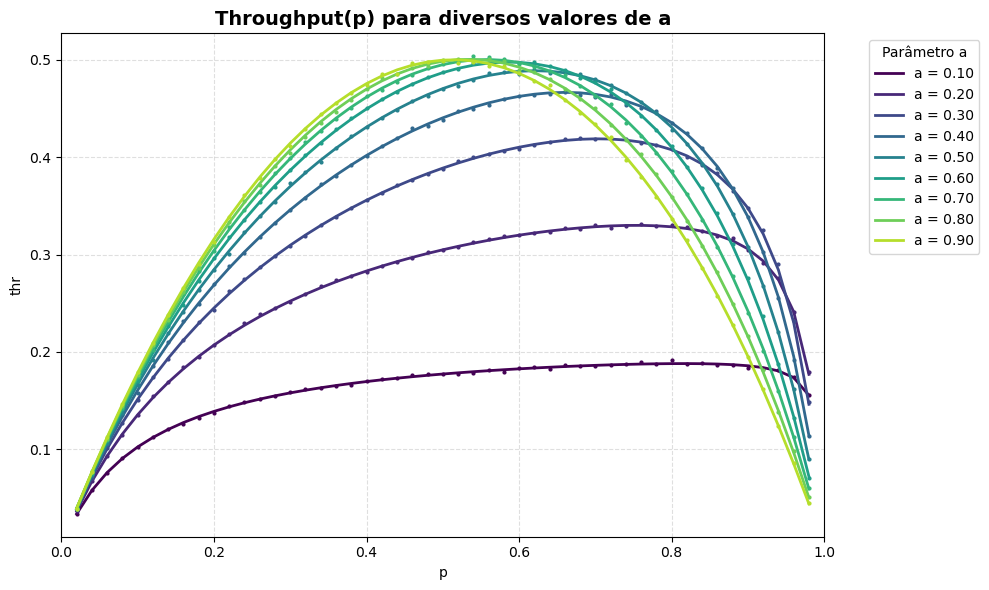

In [29]:
thr_funcao = sp.lambdify([a, p], throughput_expr, 'numpy')

# 1. Escolha um mapa de cores (ex: 'viridis', 'plasma', 'jet', 'coolwarm')
cmap = plt.get_cmap("viridis")


# 3. Use enumerete para pegar um índice (i) e calcular a cor proporcional
plt.figure(figsize=(10, 6))
for i, a_val in enumerate(a_vals):
    thr_teorico = thr_funcao(a_val, p_vals)
    thr_simulado = [sim.throughput(a_val, p, time=100000) for p in p_vals]
    # Define a cor baseada na posição do loop (0 a 1)
    color = cmap(i / len(a_vals))

    plt.plot(p_vals, thr_teorico, label=f'a = {a_val:.2f}', color=color, lw=2)
    plt.plot(p_vals, thr_simulado, color=color, linestyle="None", marker="o", markersize=2)

# --- Configurações Finais ---
plt.title('Throughput(p) para diversos valores de a', fontsize=14, fontweight='bold')
plt.xlabel('p')
plt.ylabel('thr')
plt.grid(True, linestyle='--', alpha=0.4)

# Adiciona uma barra de cores lateral para referência (opcional)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(a_vals), vmax=max(a_vals)))
# plt.colorbar(sm, label='Valor de a')

plt.legend(title='Parâmetro a', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 1)
plt.tight_layout() # Ajusta para a legenda não cortar
plt.show()

In [ ]:
# auto complete age expression
age_expr = sp.simplify((pi01 + pi10 + 2*pi11)/(throughput_expr))